# Computer Vision Assignments: Sessions 1 & 2

This notebook contains tasks and assignments based on Sessions 1 and 2. You are required to implement the functions and complete the exercises as described. Use OpenCV and other necessary libraries like NumPy and Matplotlib.

**Instructions:**
- Complete each task in the provided code cells.
- Test your implementations with sample images (e.g., download test images [here](https://sipi.usc.edu/database/database.php?volume=misc) or [here](https://www.hlevkin.com/hlevkin/06testimages.htm) or use your own test images).
- Include comments in your code for clarity.
- Display results using cv2.imshow() or Matplotlib where appropriate.
- Submit the completed notebook along with any output images or explanations on [our google drive for the CV sessions](https://drive.google.com/drive/folders/1IjVhJmAXxNQTGT-ybJ-yc5smYtR5v8CO?usp=sharing) **upload your files in a new folder under your name**

## Session 1: Basic Image Operations (Reading, Resizing, Cropping, Rotating)

### Task 1: Read and Display an Image
Read an image from a file and display it in both BGR and grayscale formats. Handle errors if the image cannot be read.

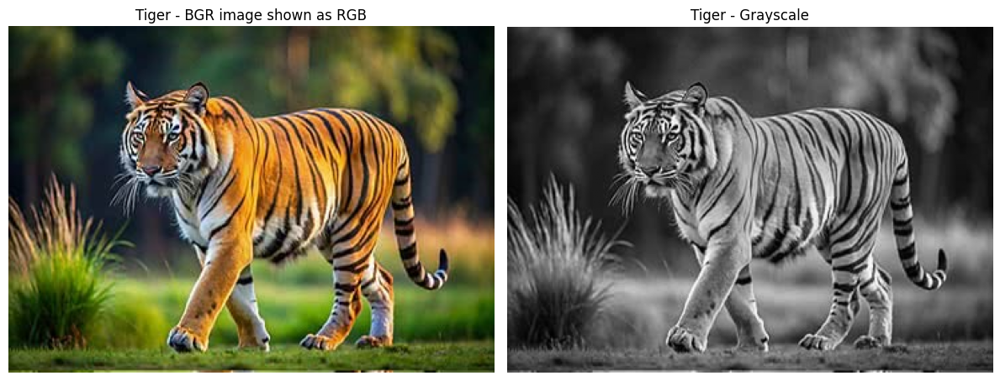

In [6]:
import cv2 as cv
import numpy as np
import sys
import matplotlib.pyplot as plt
%matplotlib inline

# Updated to use the image currently available in your environment
path = "WhatsApp Image 2026-10-04 at 11.32.06 PM.jpeg"

# Read in BGR
img = cv.imread(path)

# Handle read error
if img is None:
    raise FileNotFoundError(f"Could not read image: {path}. Please upload 'tanger.jpeg' or use a valid file path.")

# Read in Grayscale
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Display both
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title("Tiger - BGR image shown as RGB")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gray, cmap="gray")
plt.title("Tiger - Grayscale")
plt.axis("off")

plt.tight_layout()
plt.show()

### Task 2: Resize Image with Aspect Ratio Preservation
Implement resizing while preserving aspect ratio. Downscale to 60% and upscale to 200%. Compare shapes and display originals vs resized.

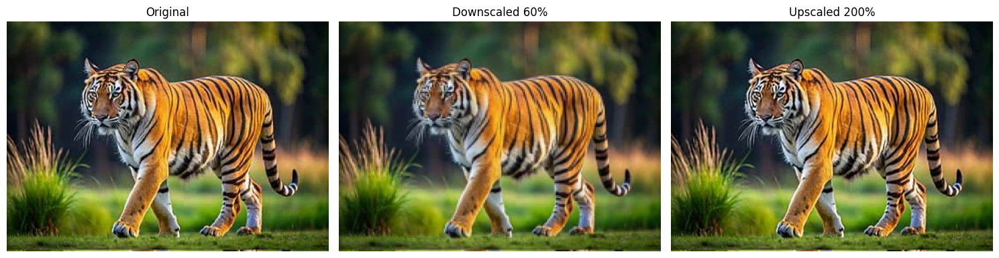

In [50]:
# Load image
# Updated to use the image currently available in your environment
img = cv.imread("WhatsApp Image 2026-10-04 at 11.32.06 PM.jpeg")
if img is None:
    raise FileNotFoundError("Could not read the tiger image. Please verify the file exists.")

h, w = img.shape[:2]

# Downscale to 60% and upscale to 200%, preserving aspect ratio
down = cv.resize(img, (0, 0), fx=0.60, fy=0.60, interpolation=cv.INTER_AREA)
up = cv.resize(img, (0, 0), fx=2.00, fy=2.00, interpolation=cv.INTER_CUBIC)



plt.figure(figsize=(15, 5))
for i, (im, title) in enumerate([
    (img, "Original"),
    (down, "Downscaled 60%"),
    (up, "Upscaled 200%")
], 1):
    plt.subplot(1, 3, i)
    plt.imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
plt.tight_layout()
plt.show()

### Task 3: Resize Without Preserving Aspect Ratio
Resize only width to 100 pixels, only height to 200 pixels, and both to (200, 200). Display and discuss distortions.

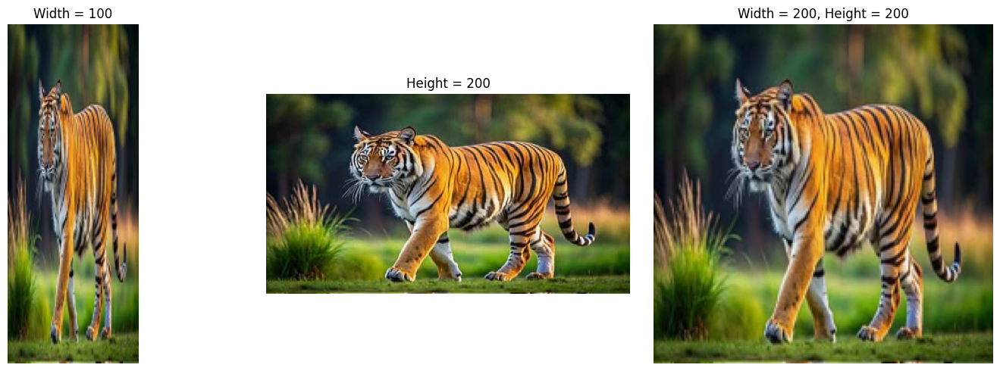

In [51]:
import cv2 as cv
import matplotlib.pyplot as plt

# Load image
# Updated to use the image currently available in your environment
img = cv.imread("WhatsApp Image 2026-10-04 at 11.32.06 PM.jpeg")
if img is None:
    raise FileNotFoundError("Could not read the tiger image. Please verify the file exists.")

# Resize without preserving aspect ratio
width_100 = cv.resize(img, (100, img.shape[0]), interpolation=cv.INTER_AREA)
height_200 = cv.resize(img, (img.shape[1], 200), interpolation=cv.INTER_AREA)
both_200 = cv.resize(img, (200, 200), interpolation=cv.INTER_AREA)

plt.figure(figsize=(15, 5))
for i, (im, title) in enumerate([
    (width_100, "Width = 100"),
    (height_200, "Height = 200"),
    (both_200, "Width = 200, Height = 200")
], 1):
    plt.subplot(1, 3, i)
    plt.imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
plt.tight_layout()
plt.show()



### Task 4: Resize Using Scale Factors (fx, fy)
Scale up by 1.2 in both directions and down by 0.6. Use different interpolations (INTER_LINEAR, INTER_NEAREST) and compare quality.

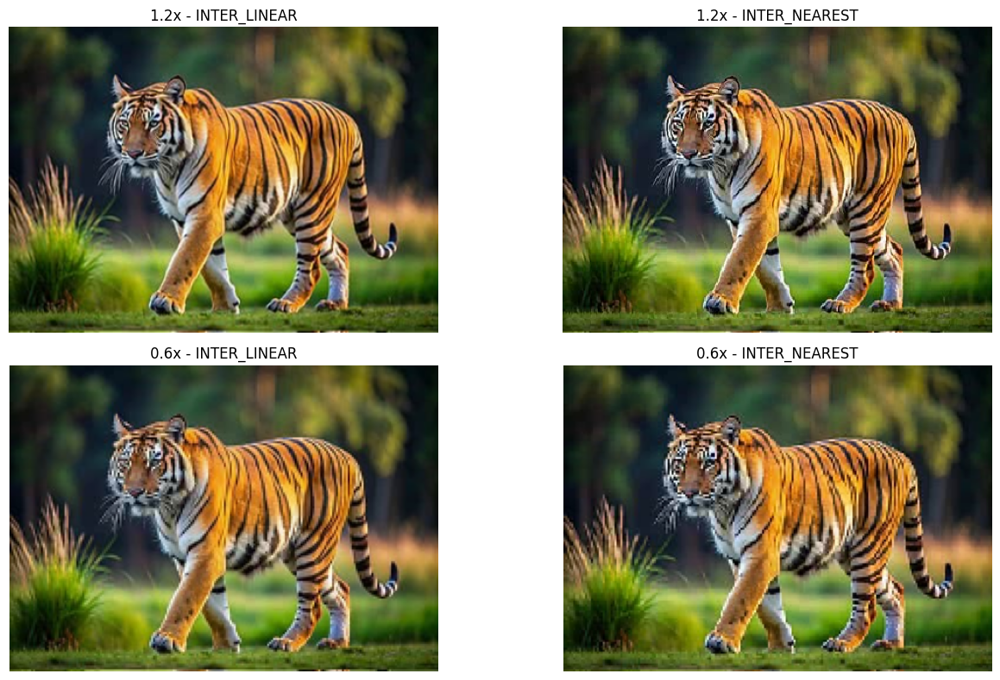

In [9]:
# Load the image using the valid filename available in your directory
img = cv.imread("WhatsApp Image 2026-10-04 at 11.32.06 PM.jpeg")
if img is None:
    raise FileNotFoundError("Could not read the tiger image. Please verify the file exists.")

up_linear = cv.resize(img, None, fx=1.2, fy=1.2, interpolation=cv.INTER_LINEAR)
up_nearest = cv.resize(img, None, fx=1.2, fy=1.2, interpolation=cv.INTER_NEAREST)
down_linear = cv.resize(img, None, fx=0.6, fy=0.6, interpolation=cv.INTER_LINEAR)
down_nearest = cv.resize(img, None, fx=0.6, fy=0.6, interpolation=cv.INTER_NEAREST)

plt.figure(figsize=(14, 8))
results = [
    (up_linear, "1.2x - INTER_LINEAR"),
    (up_nearest, "1.2x - INTER_NEAREST"),
    (down_linear, "0.6x - INTER_LINEAR"),
    (down_nearest, "0.6x - INTER_NEAREST")
]
for i, (im, title) in enumerate(results, 1):
    plt.subplot(2, 2, i)
    plt.imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
plt.tight_layout()
plt.show()

### Task 5: Cropping an Image
Crop a region (e.g., [20:200, 50:200]) from the image. Display original and cropped.

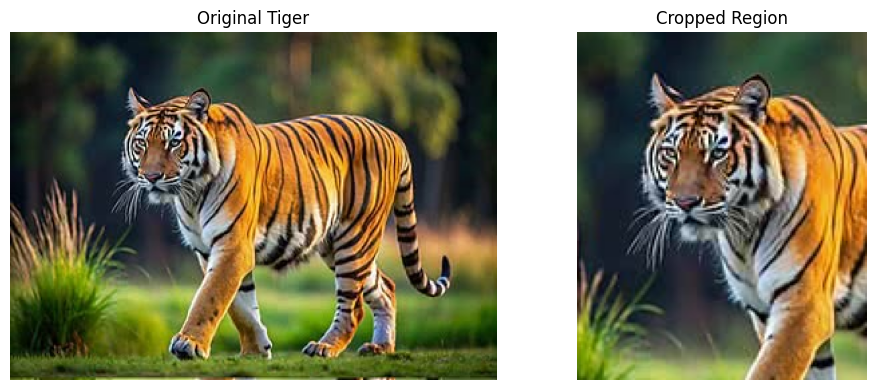

In [10]:
# Load image using the valid filename available in your directory
img = cv.imread("WhatsApp Image 2026-10-04 at 11.32.06 PM.jpeg")
if img is None:
    raise FileNotFoundError("Could not read the tiger image. Please verify the file exists.")

h, w = img.shape[:2]
# Crop: rows 20:200 and columns 50:200, clipped to image size
y2 = min(200, h)
x2 = min(200, w)
cropped = img[20:y2, 50:x2]

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title("Original Tiger")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(cropped, cv.COLOR_BGR2RGB))
plt.title("Cropped Region")
plt.axis("off")
plt.tight_layout()
plt.show()

### Task 6: Advanced Cropping - Patch Image into Blocks
Divide the image into 4 equal blocks (2x2 grid) by cropping. Display each block separately and then stitch them back using NumPy concatenation to verify.

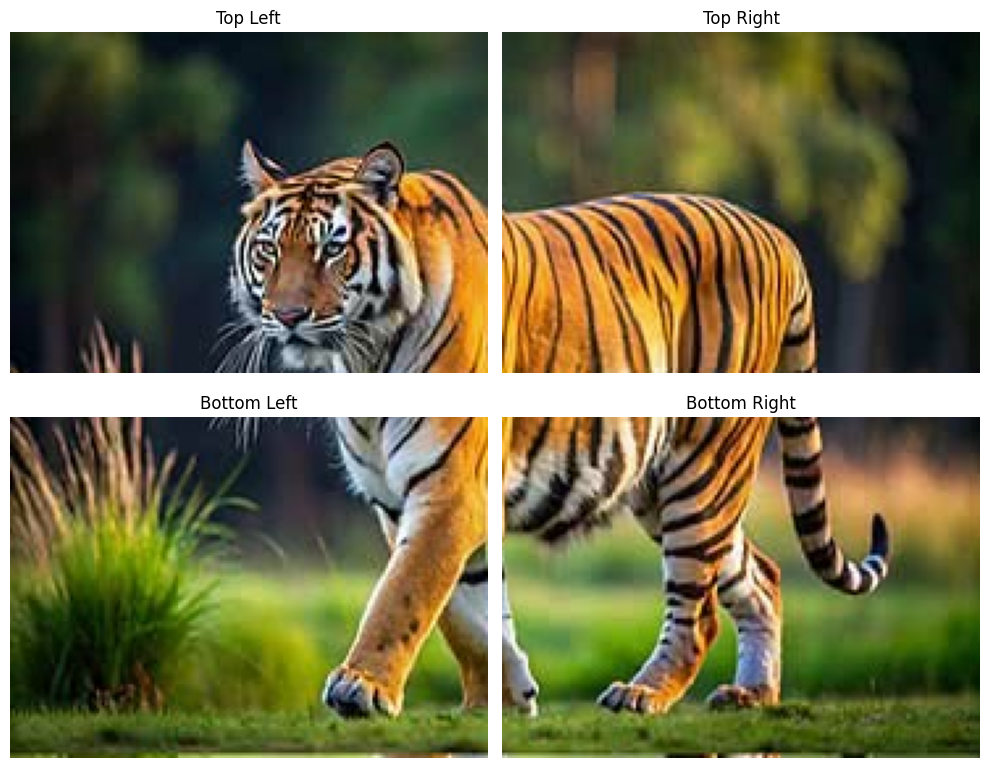

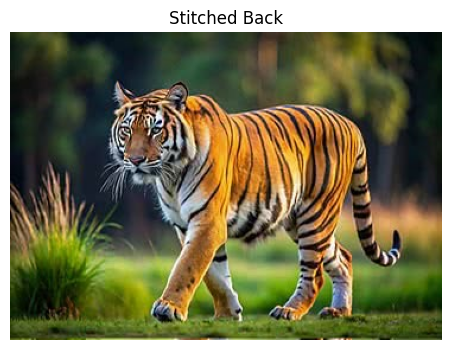

In [52]:
img = cv.imread("WhatsApp Image 2026-10-04 at 11.32.06 PM.jpeg")
if img is None:
    raise FileNotFoundError("Could not read the tiger image. Please verify the file exists.")

h, w = img.shape[:2]
mid_h, mid_w = h // 2, w // 2

# Crop into four equal blocks
top_left = img[:mid_h, :mid_w]
top_right = img[:mid_h, mid_w:]
bottom_left = img[mid_h:, :mid_w]
bottom_right = img[mid_h:, mid_w:]

# Display each block
blocks = [
    (top_left, "Top Left"),
    (top_right, "Top Right"),
    (bottom_left, "Bottom Left"),
    (bottom_right, "Bottom Right")
]
plt.figure(figsize=(10, 8))
for i, (block, title) in enumerate(blocks, 1):
    plt.subplot(2, 2, i)
    plt.imshow(cv.cvtColor(block, cv.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
plt.tight_layout()
plt.show()

# Stitch back
top = np.hstack((top_left, top_right))
bottom = np.hstack((bottom_left, bottom_right))
stitched = np.vstack((top, bottom))

plt.figure(figsize=(6, 4))
plt.imshow(cv.cvtColor(stitched, cv.COLOR_BGR2RGB))
plt.title("Stitched Back")
plt.axis("off")
plt.show()



### Task 7: Rotating an Image
Rotate the image by 45°, 90°, and 180° using getRotationMatrix2D and warpAffine. Display all rotations.

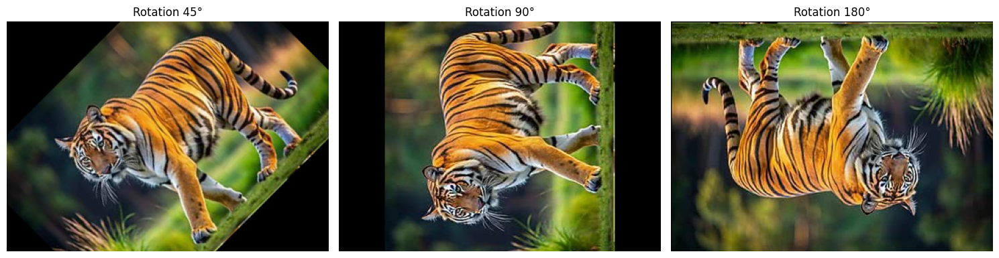

In [30]:
img = cv.imread("WhatsApp Image 2026-10-04 at 11.32.06 PM.jpeg")
if img is None:
    raise FileNotFoundError("Could not read the tiger image. Please verify the file exists.")

h, w = img.shape[:2]
center = (w // 2, h // 2)

angles = [45, 90, 180]
plt.figure(figsize=(15, 5))

for i, angle in enumerate(angles, 1):
    M = cv.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv.warpAffine(img, M, (w, h))

    plt.subplot(1, 3, i)
    plt.imshow(cv.cvtColor(rotated, cv.COLOR_BGR2RGB))
    plt.title(f"Rotation {angle}°")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Task 8: Rotate with Scaling
Rotate by 45° and scale by 0.5 in **one** operation. Compare with separate resize and rotate.

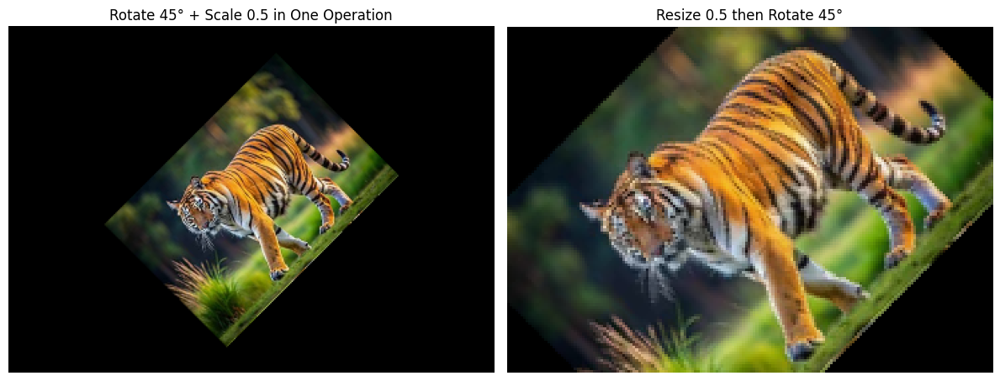

In [32]:
img = cv.imread("WhatsApp Image 2026-10-04 at 11.32.06 PM.jpeg")
if img is None:
    raise FileNotFoundError("Could not read the tiger image. Please verify the file exists.")

h, w = img.shape[:2]
center = (w // 2, h // 2)

# One operation: rotation + scale
M = cv.getRotationMatrix2D(center, 45, 0.5)
rotated_scaled = cv.warpAffine(img, M, (w, h))

# Separate operations: resize first, then rotate
resized = cv.resize(img, None, fx=0.5, fy=0.5, interpolation=cv.INTER_AREA)
rh, rw = resized.shape[:2]
M2 = cv.getRotationMatrix2D((rw // 2, rh // 2), 45, 1.0)
separate = cv.warpAffine(resized, M2, (rw, rh))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(rotated_scaled, cv.COLOR_BGR2RGB))
plt.title("Rotate 45° + Scale 0.5 in One Operation")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(separate, cv.COLOR_BGR2RGB))
plt.title("Resize 0.5 then Rotate 45°")
plt.axis("off")
plt.tight_layout()
plt.show()

## Session 2: Image Acquisition, Formats, Color Spaces, Enhancement, and Filtering

### Task 9: Read Image in Different Color Spaces
Read an image in BGR, convert to RGB (for Matplotlib), HSV, LAB and Grayscale. Display all.

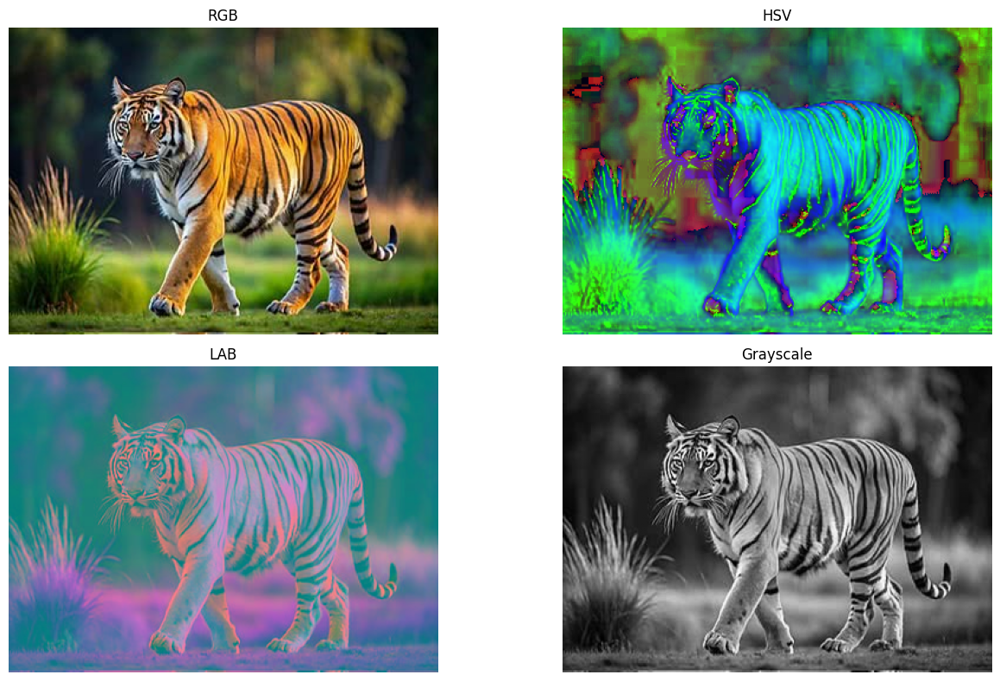

In [33]:
# Load the image using the valid filename available in your directory
img = cv.imread("WhatsApp Image 2026-10-04 at 11.32.06 PM.jpeg")
if img is None:
    raise FileNotFoundError("Could not read the tiger image. Please verify the file exists.")

# Convert to different color spaces
rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
hsv = cv.cvtColor(img, cv.COLOR_BGR2HSV)
lab = cv.cvtColor(img, cv.COLOR_BGR2LAB)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

plt.figure(figsize=(14, 8))
images_titles = [
    (rgb, "RGB", None),
    (hsv, "HSV", None),
    (lab, "LAB", None),
    (gray, "Grayscale", "gray")
]

for i, (im, title, cmap) in enumerate(images_titles, 1):
    plt.subplot(2, 2, i)
    plt.imshow(im, cmap=cmap)
    plt.title(title)
    plt.axis("off")
plt.tight_layout()
plt.show()

### Task 10: Image Sharpening
Apply cv2.blur() with a 5x5 kernel, then use cv2.filter2D() with sharpening kernels of varying strengths (e.g., [[0, -1, 0], [-1, 5, -1], [0, -1, 0]] and [[0, -2, 0], [-2, 9, -2], [0, -2, 0]]).
Compare between original and sharpened image after blurring.

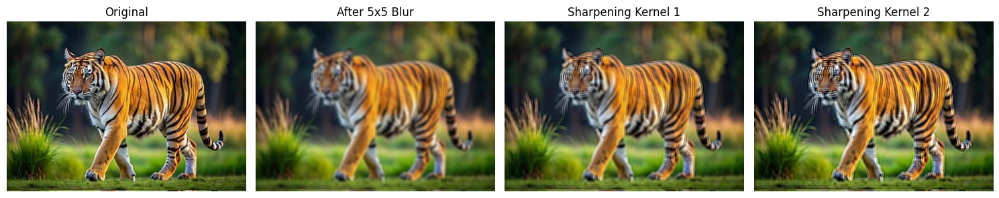

In [35]:
img = cv.imread("WhatsApp Image 2026-10-04 at 11.32.06 PM.jpeg")
if img is None:
    raise FileNotFoundError("Could not read the tiger image. Please verify the file exists.")

blurred = cv.blur(img, (5, 5))

kernel1 = np.array([[0, -1, 0],
                    [-1, 5, -1],
                    [0, -1, 0]], dtype=np.float32)

kernel2 = np.array([[0, -2, 0],
                    [-2, 9, -2],
                    [0, -2, 0]], dtype=np.float32)

sharp1 = cv.filter2D(blurred, -1, kernel1)
sharp2 = cv.filter2D(blurred, -1, kernel2)

plt.figure(figsize=(15, 4))
results = [
    (img, "Original"),
    (blurred, "After 5x5 Blur"),
    (sharp1, "Sharpening Kernel 1"),
    (sharp2, "Sharpening Kernel 2")
]
for i, (im, title) in enumerate(results, 1):
    plt.subplot(1, 4, i)
    plt.imshow(cv.cvtColor(im, cv.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
plt.tight_layout()
plt.show()

### Task 11: Add Salt and Pepper Noise to Image
Implement a function to add salt and pepper noise to an image. Control noise density (e.g., 0.05).

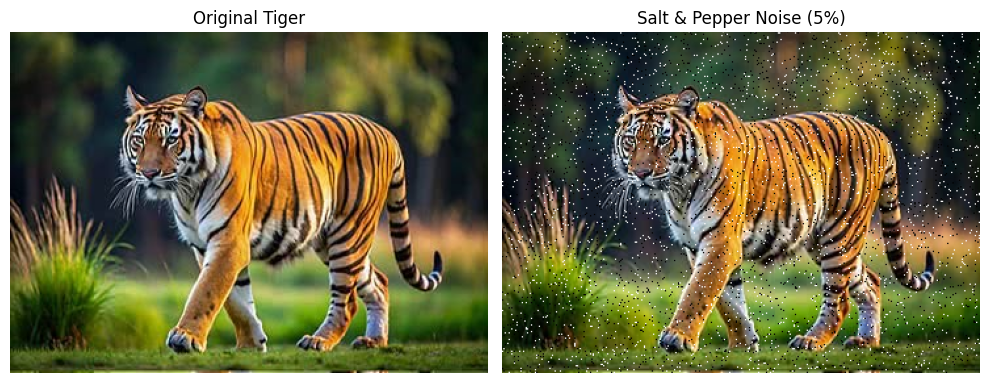

In [39]:
def add_salt_pepper_noise(image, density=0.05):
    """Add salt-and-pepper noise with the requested density."""
    noisy = image.copy()
    total_pixels = image.shape[0] * image.shape[1]
    num_noisy = int(total_pixels * density)

    rng = np.random.default_rng(42)
    ys = rng.integers(0, image.shape[0], num_noisy)
    xs = rng.integers(0, image.shape[1], num_noisy)

    half = num_noisy // 2
    noisy[ys[:half], xs[:half]] = 0       # pepper
    noisy[ys[half:], xs[half:]] = 255     # salt
    return noisy

img = cv.imread("WhatsApp Image 2026-10-04 at 11.32.06 PM.jpeg")
if img is None:
    raise FileNotFoundError("Could not read the tiger image. Please verify the file exists.")

noisy = add_salt_pepper_noise(img, density=0.05)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title("Original Tiger")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(noisy, cv.COLOR_BGR2RGB))
plt.title("Salt & Pepper Noise (5%)")
plt.axis("off")
plt.tight_layout()
plt.show()

### Task 12: Remove Salt and Pepper Noise Using Median Filter
Apply cv.medianBlur() to a noisy image. Experiment with kernel sizes (3,5,7) and compare results.

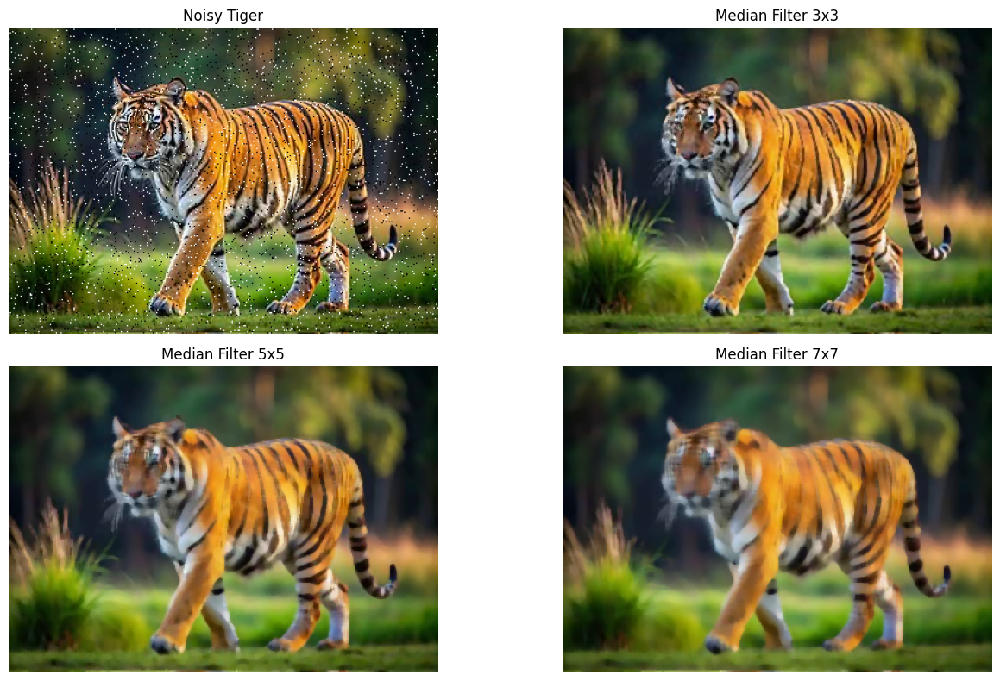

In [53]:
img = cv.imread("WhatsApp Image 2026-10-04 at 11.32.06 PM.jpeg")
if img is None:
    raise FileNotFoundError("Could not read the tiger image. Please verify the file exists.")

noisy = add_salt_pepper_noise(img, density=0.05)

kernel_sizes = [3, 5, 7]
plt.figure(figsize=(14, 8))

plt.subplot(2, 2, 1)
plt.imshow(cv.cvtColor(noisy, cv.COLOR_BGR2RGB))
plt.title("Noisy Tiger")
plt.axis("off")

for i, k in enumerate(kernel_sizes, 2):
    filtered = cv.medianBlur(noisy, k)
    plt.subplot(2, 2, i)
    plt.imshow(cv.cvtColor(filtered, cv.COLOR_BGR2RGB))
    plt.title(f"Median Filter {k}x{k}")
    plt.axis("off")

plt.tight_layout()
plt.show()